In [1]:
2+2

4

In [2]:
import torch
import time

N = 3200
D = 2048

embeddings = torch.randn(N, D)
query = torch.randn(D)

embeddings = torch.nn.functional.normalize(
    embeddings,
    dim=1
)

query = torch.nn.functional.normalize(
    query,
    dim=0
)

start = time.perf_counter()

scores = embeddings @ query

topk_scores, topk_idx = torch.topk(
    scores,
    k=10
)

end = time.perf_counter()

print(f"Time: {(end-start)*1000:.3f} ms")

ModuleNotFoundError: No module named 'torch'

In [2]:
import numpy as np
from typing import Union, Tuple, Optional, List
# from draw import draw_dot
from typing import Union

TensorLike = Union[
    'Tensor',
    int,
    float,
    list,
    tuple,
    np.ndarray,
    np.number
]

In [3]:
#------TENSOR------
# __init__, __repr__, shape, dtype, size, ndim, numpy, zero_grad, backward, 
# reshape, transpose, flatten, squeeze, expand_dims, __getitem__, __add__, __radd__, 
# __sub__, __rsub__, __mul__, __rmul__, __truediv__, __rtruediv__, __pow__, __neg__, 
# __matmul__, sum, mean, max, exp, log, sqrt, abs,
#  zeros, ones, randn, rand, arange


#backward, 

In [4]:


import numpy as np
from typing import Union, Tuple, Optional, List
# from draw import draw_dot
from typing import Union

TensorLike = Union[
    'Tensor',
    int,
    float,
    list,
    tuple,
    np.ndarray,
    np.number
]

class Tensor:
    def __init__(
        self,
        data: Union['Tensor',np.ndarray,float,int,list],
        requires_grad: bool = False,
        is_leaf: bool = True,
        dtype: np.dtype = np.float32,
        
    ):
        
        if not isinstance(requires_grad, bool):
            raise TypeError(
                f"requires_grad must be bool, got {type(requires_grad).__name__}"
            )

        if not isinstance(is_leaf, bool):
            raise TypeError(
                f"is_leaf must be bool, got {type(is_leaf).__name__}"
            )
        
        if isinstance(data, Tensor):
            data = data.data

        try:
            self.data = np.array(data, dtype=dtype)
        except Exception:
            raise TypeError(
                f"Unsupported data type: {type(data)}"
            )

        self.requires_grad = requires_grad
        self.grad = None
        self.is_leaf = is_leaf
        self._backward = lambda: None
        self._prev = set()
        self._op = ""

    def __repr__(self) -> str:
        """String representation."""
        return f"Tensor({self.data.tolist()}, shape={self.shape}, dtype={self.dtype}, requires_grad={self.requires_grad})"

    @property
    def shape(self) -> Tuple[int, ...]:
        """Get tensor shape."""
        return self.data.shape
    
    @property
    def dtype(self) -> np.dtype:
        """Get data type."""
        return self.data.dtype
    
    @property
    def size(self) -> int:
        """Total number of elements."""
        return self.data.size
    
    @property
    def ndim(self) -> int:
        "Number of dimensions"
        return self.data.ndim
    
    @property
    def T(self):
        return self.transpose()

    def numpy(self) -> np.ndarray:
        """Get underlying NumPy array."""
        return self.data

    def zero_grad(self):
        self.grad = None


    def __add__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other,dtype=self.dtype)
        result = self.data + other.data
        out = Tensor(
            result,
            requires_grad=(self.requires_grad or other.requires_grad),
            is_leaf=False,
            dtype=result.dtype
        )
        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                
                grad_self = out.grad
                grad_other = out.grad

                while grad_self.ndim > len(self.shape):
                    grad_self = grad_self.sum(axis=0)

                for axis, size in enumerate(self.shape):
                    if size == 1 and grad_self.shape[axis] != 1:
                        grad_self = grad_self.sum(
                            axis=axis,
                            keepdims=True
                        )

                # Reduce broadcasted dimensions for other
                while grad_other.ndim > len(other.shape):
                    grad_other = grad_other.sum(axis=0)

                for axis, size in enumerate(other.shape):
                    if size == 1 and grad_other.shape[axis] != 1:
                        grad_other = grad_other.sum(
                            axis=axis,
                            keepdims=True
                        )

                if self.requires_grad:
                    if self.grad is None:
                        self.grad = grad_self
                    else:
                        self.grad += grad_self

                if other.requires_grad:
                    if other.grad is None:
                        other.grad = grad_other
                    else:
                        other.grad += grad_other

            out._backward = _backward
            out._prev = {self, other}
            out._op = "+"

        return out


    def __radd__(self, other: TensorLike) -> 'Tensor':
        """Right addition."""
        return self + other
    
    def __mul__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other, dtype=self.dtype)
        result = self.data * other.data
        out = Tensor(
            result,
            requires_grad=(self.requires_grad or other.requires_grad),
            is_leaf=False,
            dtype=result.dtype
        )
        if out.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                # d(a*b)/da = b
                grad_self = out.grad * other.data
                # d(a*b)/db = a
                grad_other = out.grad * self.data
                # Reduce broadcasted dimensions for self
                while grad_self.ndim > len(self.shape):
                    grad_self = grad_self.sum(axis=0)

                for axis, size in enumerate(self.shape):
                    if size == 1 and grad_self.shape[axis] != 1:
                        grad_self = grad_self.sum(
                            axis=axis,
                            keepdims=True
                        )
                # Reduce broadcasted dimensions for other
                while grad_other.ndim > len(other.shape):
                    grad_other = grad_other.sum(axis=0)
                for axis, size in enumerate(other.shape):
                    if size == 1 and grad_other.shape[axis] != 1:
                        grad_other = grad_other.sum(
                            axis=axis,
                            keepdims=True
                      )
                if self.requires_grad:
                    if self.grad is None:
                        self.grad = grad_self
                    else:
                        self.grad += grad_self
                if other.requires_grad:
                    if other.grad is None:
                        other.grad = grad_other
                    else:
                        other.grad += grad_other
            out._backward = _backward
            out._prev = {self, other}
            out._op = "*"
        return out
    
    def __rmul__(self, other: TensorLike) -> 'Tensor':
        """Right multiplication."""
        return self * other

    def __neg__(self) -> 'Tensor':
        """Negation."""
        return self * (-1)

    def __sub__(self, other: TensorLike) -> 'Tensor':
        """Element-wise subtraction."""
        return self + (-other if isinstance(other, Tensor) else -other)
    
    def __rsub__(self, other: TensorLike) -> 'Tensor':
        """Right subtraction."""
        return other + (-self)
    
    def __pow__(self, power : Union[int,float]) -> 'Tensor':
        if not isinstance(power, (int, float)):
            raise TypeError(
                f"power must be int or float, got {type(power).__name__}"
            )
        result = self.data ** power
        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )
        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                
                grad = (out.grad * power * (self.data ** (power - 1)))
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = f"**{power}"

        return out

    def __truediv__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other)
        return self * (other ** -1)

    def __rtruediv__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other)
        return other * (self ** -1)

    


    def reshape(self, *shape: int) -> 'Tensor':
        if len(shape) == 1:
            if isinstance(shape[0], (tuple, list)):
                new_shape = tuple(shape[0])
            elif isinstance(shape[0], int):
                new_shape = (shape[0],)
            else:
                raise TypeError(
                    f"reshape() expected ints, tuple, or list, got {type(shape[0]).__name__}"
                )
        else:
            new_shape = tuple(shape)

        # Validate dimensions
        for dim in new_shape:
            if not isinstance(dim, int):
                raise TypeError(
                    f"shape dimensions must be integers, got {type(dim).__name__}"
                )

        input_shape = self.shape

        try:
            result = self.data.reshape(new_shape)
        except ValueError as e:
            raise ValueError(
                f"Cannot reshape tensor of shape {self.shape} "
                f"to shape {new_shape}"
            ) from e

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = out.grad.reshape(input_shape)
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad
            out._backward = _backward
            out._prev = {self}
            out._op = "reshape"

        return out
    
    def transpose(self, axes = None) -> 'Tensor':
        if axes is None:
            axes = tuple(reversed(range(self.ndim)))
        if not isinstance(axes,tuple):
            raise TypeError(
                f"axes must be a tuple, got {type(axes).__name__}")
        if len(axes) != self.ndim:
            raise ValueError(
                f"axes length ({len(axes)}) must match tensor ndim ({self.ndim})")
        if sorted(axes) != list(range(self.ndim)):
            raise ValueError(
                f"invalid axis permutation {axes}")
        
        out = Tensor(
            np.transpose(self.data, axes),
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=self.dtype
        )
        if self.requires_grad:
            reverse_axes = tuple(np.argsort(axes))
            def _backward():
                if out.grad is None:
                        return
                grad = np.transpose(
                    out.grad,
                    reverse_axes
                )
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad
            out._backward = _backward
            out._prev = {self}
            out._op = "transpose"

        return out

    def flatten(self) -> 'Tensor':
        original_shape = self.shape
        out = Tensor(self.data.flatten(),requires_grad=self.requires_grad,is_leaf=False,dtype=self.dtype)

        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = out.grad.reshape(original_shape)

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "flatten"
        return out

    def squeeze(self, axis: Optional[Union[int, Tuple[int, ...]]] = None) -> 'Tensor':
        original_shape = self.shape
        if axis is not None:
            if isinstance(axis, int):
                axis = (axis,)
            elif not isinstance(axis, tuple):
                raise TypeError(
                    f"axis must be int, tuple of ints, or None, "
                    f"got {type(axis).__name__}")
            
            normalized_axes = []
            for ax in axis:
                if not isinstance(ax, int):
                    raise TypeError(
                        f"axis values must be integers, got {type(ax).__name__}"
                    )
                if ax < -self.ndim or ax >= self.ndim:
                    raise ValueError(
                        f"axis {ax} is out of bounds "
                        f"for tensor of dimension {self.ndim}"
                    )
                if ax < 0:
                    ax += self.ndim
                if self.shape[ax] != 1:
                    raise ValueError(
                        f"cannot squeeze axis {ax} "
                        f"with size {self.shape[ax]}"
                    )
                normalized_axes.append(ax)

            axis = tuple(sorted(set(normalized_axes)))

        try:
            result = np.squeeze(self.data, axis=axis)
        except ValueError as e:
            raise ValueError(str(e)) from e

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype)

        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = out.grad.reshape(original_shape)
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad
        
            out._backward = _backward
            out._prev = {self}
            out._op = "squeeze"

        return out

    def expand_dims(self, axis: int) -> 'Tensor':
        if not isinstance(axis, int):
            raise TypeError(
                f"axis must be int, got {type(axis).__name__}"
            )
        # For expand_dims, valid range is [-ndim-1, ndim]
        if axis < -(self.ndim + 1) or axis > self.ndim:
            raise ValueError(
                f"axis {axis} is out of bounds "
                f"for tensor of dimension {self.ndim}"
            )

        original_shape = self.shape
        if axis < 0:
            axis += self.ndim + 1
        result = np.expand_dims(self.data, axis)
        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )
        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = np.squeeze(out.grad, axis=axis)
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad
            out._backward = _backward
            out._prev = {self}
            out._op = "expand_dims"

        return out
    
    def __getitem__(self, key) -> 'Tensor':
        result = self.data[key]
        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )
        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = np.zeros_like(self.data)
                grad[key] = out.grad
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "getitem"

        return out

    def _sum_to_shape(grad: np.ndarray,
                    shape: Tuple[int, ...]) -> np.ndarray:
        """
        Reduce broadcasted gradient back to original shape.
        """

        while grad.ndim > len(shape):
            grad = grad.sum(axis=0)

        for axis, size in enumerate(shape):
            if size == 1 and grad.shape[axis] != 1:
                grad = grad.sum(
                    axis=axis,
                    keepdims=True
                )

        return grad

    def __matmul__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other, dtype=self.dtype)

        try:
            result = self.data @ other.data
        except ValueError as e:
            raise ValueError(
                f"Cannot matmul tensors with shapes "
                f"{self.shape} and {other.shape}"
            ) from e

        out = Tensor(
            result, requires_grad=(
                self.requires_grad or
                other.requires_grad
            ),
            is_leaf=False,
            dtype=result.dtype
        )

        if out.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                if self.requires_grad:
                    grad_self = (
                            np.swapaxes(other.data, -1, -2)
                            @ out.grad
                        )
                    grad_self = Tensor._sum_to_shape(
                        grad_self,
                        self.shape
                    )
                    if self.grad is None:
                        self.grad = grad_self
                    else:
                        self.grad += grad_self
                if other.requires_grad:
                    grad_other = (
                            np.swapaxes(self.data, -1, -2)
                            @ out.grad
                        )
                    grad_other = Tensor._sum_to_shape(
                        grad_other,
                        other.shape
                    )
                    if other.grad is None:
                        other.grad = grad_other
                    else:
                        other.grad += grad_other

            out._backward = _backward
            out._prev = {self, other}
            out._op = "matmul"

        return out
    
    def sum(
        self,
        axis: Optional[Union[int, Tuple[int, ...]]] = None,
        keepdims: bool = False
    ) -> 'Tensor':

        result = np.sum(
            self.data,
            axis=axis,
            keepdims=keepdims
        )

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:
            original_shape = self.shape

            def _backward():
                if out.grad is None:
                    return

                grad = out.grad

                if axis is not None and not keepdims:
                    axes = (axis,) if isinstance(axis, int) else axis

                    for ax in sorted(
                        [a if a >= 0 else a + self.ndim for a in axes]
                    ):
                        grad = np.expand_dims(grad, ax)

                grad = np.broadcast_to(
                    grad,
                    original_shape
                )

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "sum"

        return out

    def mean(
        self,
        axis: Optional[Union[int, Tuple[int, ...]]] = None,
        keepdims: bool = False
    ) -> 'Tensor':

        result = np.mean(
            self.data,
            axis=axis,
            keepdims=keepdims
        )

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:

            if axis is None:
                count = self.data.size
            else:
                axes = (axis,) if isinstance(axis, int) else axis
                count = 1
                for ax in axes:
                    count *= self.shape[ax]

            original_shape = self.shape

            def _backward():
                if out.grad is None:
                    return

                grad = out.grad

                if axis is not None and not keepdims:
                    axes = (axis,) if isinstance(axis, int) else axis

                    for ax in sorted(
                        [a if a >= 0 else a + self.ndim for a in axes]
                    ):
                        grad = np.expand_dims(grad, ax)

                grad = np.broadcast_to(
                    grad,
                    original_shape
                ) / count

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "mean"

        return out

    def max(
        self,
        axis: Optional[int] = None,
        keepdims: bool = False
    ) -> 'Tensor':

        result = np.max(
            self.data,
            axis=axis,
            keepdims=keepdims
        )

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:

            def _backward():
                if out.grad is None:
                    return

                if axis is None:
                    mask = (self.data == result)

                    grad = mask.astype(self.dtype) * out.grad

                else:
                    max_vals = result

                    if not keepdims:
                        max_vals = np.expand_dims(
                            max_vals,
                            axis
                        )

                    mask = (self.data == max_vals)

                    grad = out.grad

                    if not keepdims:
                        grad = np.expand_dims(
                            grad,
                            axis
                        )

                    grad = mask.astype(self.dtype) * grad

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "max"

        return out
    
    def exp(self) -> 'Tensor':

        result = np.exp(self.data)

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:

            def _backward():
                if out.grad is None:
                    return

                grad = out.grad * result

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "exp"

        return out

    def log(self) -> 'Tensor':

        result = np.log(self.data)

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:

            def _backward():
                if out.grad is None:
                    return

                grad = out.grad / self.data

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "log"

        return out
    
    def sqrt(self) -> 'Tensor':

        result = np.sqrt(self.data)

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:

            def _backward():
                if out.grad is None:
                    return

                grad = out.grad / (2 * result)

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "sqrt"

        return out

    def abs(self) -> 'Tensor':

        result = np.abs(self.data)

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:

            def _backward():
                if out.grad is None:
                    return

                grad = out.grad * np.sign(self.data)

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "abs"

        return out
    
    @staticmethod
    def zeros(
        *shape,
        requires_grad: bool = False,
        dtype=np.float32
    ) -> 'Tensor':

        if len(shape) == 1:
            if isinstance(shape[0], Tensor):
                shape = tuple(int(x) for x in shape[0].data.flatten())
            elif isinstance(shape[0], (tuple, list, np.ndarray)):
                shape = tuple(int(x) for x in shape[0])

        return Tensor(
            np.zeros(shape, dtype=dtype),
            requires_grad=requires_grad,
            dtype=dtype
        )


    @staticmethod
    def ones(
        *shape,
        requires_grad: bool = False,
        dtype=np.float32
    ) -> 'Tensor':

        if len(shape) == 1:
            if isinstance(shape[0], Tensor):
                shape = tuple(int(x) for x in shape[0].data.flatten())
            elif isinstance(shape[0], (tuple, list, np.ndarray)):
                shape = tuple(int(x) for x in shape[0])

        return Tensor(
            np.ones(shape, dtype=dtype),
            requires_grad=requires_grad,
            dtype=dtype
        )


    @staticmethod
    def randn(
        *shape,
        requires_grad: bool = False,
        dtype=np.float32
    ) -> 'Tensor':

        if len(shape) == 1:
            if isinstance(shape[0], Tensor):
                shape = tuple(int(x) for x in shape[0].data.flatten())
            elif isinstance(shape[0], (tuple, list, np.ndarray)):
                shape = tuple(int(x) for x in shape[0])

        return Tensor(
            np.random.randn(*shape).astype(dtype),
            requires_grad=requires_grad,
            dtype=dtype
        )


    @staticmethod
    def rand(
        *shape,
        requires_grad: bool = False,
        dtype=np.float32
    ) -> 'Tensor':

        if len(shape) == 1:
            if isinstance(shape[0], Tensor):
                shape = tuple(int(x) for x in shape[0].data.flatten())
            elif isinstance(shape[0], (tuple, list, np.ndarray)):
                shape = tuple(int(x) for x in shape[0])

        return Tensor(
            np.random.rand(*shape).astype(dtype),
            requires_grad=requires_grad,
            dtype=dtype
        )


    @staticmethod
    def arange(
        start,
        stop=None,
        step=1,
        requires_grad: bool = False,
        dtype=np.float32
    ) -> 'Tensor':

        if isinstance(start, Tensor):
            start = start.data.item()

        if isinstance(stop, Tensor):
            stop = stop.data.item()

        if isinstance(step, Tensor):
            step = step.data.item()

        if stop is None:
            start, stop = 0, start

        return Tensor(
            np.arange(
                start,
                stop,
                step,
                dtype=dtype
            ),
            requires_grad=requires_grad,
            dtype=dtype
        )

In [5]:
a = Tensor(
    [[4,5,6],
      [6,7,8]]
)

a.sum(axis=(0,1),keepdims=False)

Tensor(36.0, shape=(), dtype=float32, requires_grad=False)

In [26]:
import sys
import os

# sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

from tensor import Tensor

class Module:
    """Base class for all neural network layers and models."""
    def __init__(self):
        self.__dict__['_parameters'] = {}
        self.__dict__['_modules'] = {}
        self.__dict__['training'] = True
    
    def __setattr__(self, name: str, value):
        _params = self.__dict__.get("_parameters",{})
        _mods = self.__dict__.get('_modules',{})
        _params.pop(name, None)
        _mods.pop(name, None)
        if isinstance(value, Tensor) and value.requires_grad:
            _params[name] = value
        elif isinstance(value, Module):
            _mods[name] = value
        object.__setattr__(self, name, value)

    def parameters(self):
        """Yield all learnable parameters recursively."""
        for p in self._parameters.values():
            yield p
        for mod in self._modules.values():
            yield from mod.parameters()

    def zero_grad(self):
        for p in self.parameters():
            p.zero_grad()

    def train(self, mode: bool = True):
        self.__dict__['training'] = mode
        for mod in self._modules.values():
            mod.train(mode)
        return self

    def eval(self):
        return self.train(mode=False)
    
    def forward(self, *args, **kwargs):
        raise NotImplementedError(f"{self.__class__.__name__}.forward() not implemented")

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

    def __repr__(self):
        lines = [self.__class__.__name__ + "("]
        for name, mod in self._modules.items():
            lines.append(f"  ({name}): {repr(mod)}")
        lines.append(")")
        return "\n".join(lines)
        

In [28]:
import numpy as np
import sys
import os
# sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

from tensor import Tensor
# from .module import Module


class Linear(Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True, dtype = np.float32, init: str = "kaiming"):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.dtype = dtype
        self.init = init
        
        std = self._initialize_weights()
        self.W = Tensor.randn((in_features,out_features),requires_grad=True,
                              dtype=self.dtype) * std

        if bias:
            self.b = Tensor.zeros(out_features, dtype=self.dtype,requires_grad=True)
        else:
            self.b = None

    def _initialize_weights(self):

        if self.init == "kaiming":
            std = np.sqrt(2.0 / self.in_features)
            return std
            
        elif self.init == "xavier":
            std = np.sqrt(2.0 / (self.in_features + self.out_features))
            return std

        elif self.init == "normal":
            std = 0.01
            return std

        else:
            raise ValueError(
                f"Unknown initialization method: {self.init}"
            )

    def forward(self,x):
        if x.dtype != self.W.dtype:
            x = x.astype(self.W.dtype)
        out = x @ self.W
        if self.b is not None:
            out = out + self.b
        return out

    def to(self, dtype):
        self.dtype = dtype
        self.W.data = self.W.data.astype(dtype)
        if self.W.grad is not None:
            self.W.grad = self.W.grad.astype(dtype)
        if self.b is not None:
            self.b.data = self.b.data.astype(dtype)
            if self.b.grad is not None:
                self.b.grad = self.b.grad.astype(dtype)
        return self
    
    def float(self):
        return self.to(np.float32)

    def double(self):
        return self.to(np.float64)

    def half(self):
        return self.to(np.float16)

    def __repr__(self):
        return f"Linear(in={self.in_features}, out={self.out_features}, bias={self.b is not None}, dtype={self.dtype}, init='{self.init}')"


In [29]:

print("=" * 50)
print("1. Constructor")
print("=" * 50)

linear = Linear(10, 5)

print(linear)
print("W shape:", linear.W.shape)
print("W dtype:", linear.W.dtype)
print("W requires_grad:", linear.W.requires_grad)

if linear.b is not None:
    print("b shape:", linear.b.shape)
    print("b dtype:", linear.b.dtype)
    print("b requires_grad:", linear.b.requires_grad)


print("\n" + "=" * 50)
print("2. Forward Pass")
print("=" * 50)

x = Tensor.randn((4, 10))
y = linear(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

assert y.shape == (4, 5)

print("✓ Forward pass works")


print("\n" + "=" * 50)
print("3. Dtype Conversion")
print("=" * 50)

linear.half()

print("W dtype after half():", linear.W.dtype)

if linear.b is not None:
    print("b dtype after half():", linear.b.dtype)

assert linear.W.dtype == np.float16

linear.float()

print("W dtype after float():", linear.W.dtype)

assert linear.W.dtype == np.float32

linear.double()

print("W dtype after double():", linear.W.dtype)

assert linear.W.dtype == np.float64

print("✓ Dtype conversion works")


print("\n" + "=" * 50)
print("4. Input Dtype Auto Cast")
print("=" * 50)

linear.half()

x = Tensor.randn((2, 10), dtype=np.float32)

print("Input dtype :", x.dtype)
print("Weight dtype:", linear.W.dtype)

y = linear(x)

print("Output dtype:", y.dtype)

print("✓ Auto casting works")


print("\n" + "=" * 50)
print("5. Weight Initialization")
print("=" * 50)

kaiming = Linear(100, 50, init="kaiming")
xavier = Linear(100, 50, init="xavier")
normal = Linear(100, 50, init="normal")

print("Kaiming std:", kaiming.W.data.std())
print("Xavier std :", xavier.W.data.std())
print("Normal std :", normal.W.data.std())

print("✓ Initialization works")


print("\n" + "=" * 50)
print("6. Parameter Check")
print("=" * 50)

print("W requires_grad:", linear.W.requires_grad)

if linear.b is not None:
    print("b requires_grad:", linear.b.requires_grad)

assert linear.W.requires_grad

print("✓ Parameters registered")


print("\n" + "=" * 50)
print("7. Leaf Tensor Check")
print("=" * 50)

print("grad_fn:", getattr(linear.W, "grad_fn", None))
print("_prev :", getattr(linear.W, "_prev", None))

print("Inspect manually:")
print("If grad_fn is not None because of '* std',")
print("W may be a non-leaf tensor.")

print("\nALL TESTS FINISHED")


1. Constructor
Linear(in=10, out=5, bias=True, dtype=<class 'numpy.float32'>, init='kaiming')
W shape: (10, 5)
W dtype: float32
W requires_grad: True
b shape: (5,)
b dtype: float32
b requires_grad: True

2. Forward Pass
Input shape : (4, 10)
Output shape: (4, 5)
✓ Forward pass works

3. Dtype Conversion
W dtype after half(): float16
b dtype after half(): float16
W dtype after float(): float32
W dtype after double(): float64
✓ Dtype conversion works

4. Input Dtype Auto Cast
Input dtype : float32
Weight dtype: float16


AttributeError: 'Tensor' object has no attribute 'astype'

In [25]:
import torch
import torch.nn as nn

linear = nn.Linear(3,2,dtype=torch.float64)
linear.double()
print(linear.weight.dtype)
print(linear.bias.dtype)

torch.float64
torch.float64


In [7]:
import numpy as np
import sys
import os
# sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

from tensor import Tensor
from nn.module import Module




In [8]:
class Student:
    def __setattr__(self, name, value):
        print(f"Putting {value} into {name}")

s = Student()
s.name = "John"
print(s.name)

Putting John into name


AttributeError: 'Student' object has no attribute 'name'

In [ ]:
np.argsort((2,0,1))

array([1, 2, 0])

In [ ]:
import torch

x = torch.tensor(2.0)

print(x)

tensor(2.)


In [ ]:
import numpy as np

a = np.array([[1, 2, 3]])
print(a.shape)
b = np.transpose(2)

print(b.shape)
b

(1, 3)
()


array(2)

In [ ]:
x = Tensor([1.0, 2.0, 3.0], requires_grad=True)
w = Tensor([4.0, 5.0, 6.0], requires_grad=True)

a = x * w
print("A",a.data)
b = a + 3
print("B",b.data)
c = b ** 2
print("C",c.data)

A [ 4. 10. 18.]
B [ 7. 13. 21.]
C [ 49. 169. 441.]


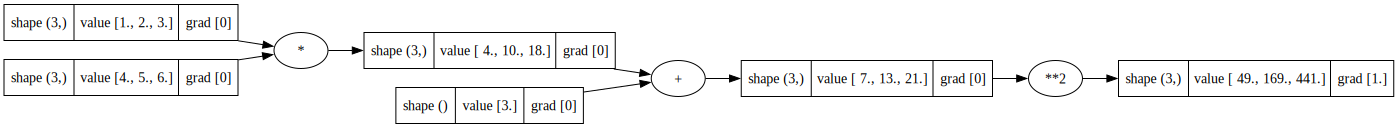

In [ ]:

c.grad = 1.0
draw_dot(c)

In [ ]:
a  = 10
b =  5

a * (b**-1)

2.0

In [ ]:
def add(x: int, y: int) -> int:
    return x + y

add("hello", "world")

'helloworld'

In [ ]:
import torch 

a = torch.tensor([2,34,5])
b = 5

a.__add__(b)

tensor([ 7, 39, 10])

In [ ]:
a = np.array([1,23,4])
a.size

3